## Goal of this notebook 

(Following module 5 of https://ml-learn.mds.ubc.ca/en/)

- Identify when to implement feature transformations such as **imputation** and **scaling**.
- Apply `sklearn.pipeline.Pipeline` to build a machine learning **pipeline**.
- Use `sklearn` for applying numerical **feature transformations** on the data.
- Discuss the **golden rule** in the context of feature transformations.
- Carry out **hyperparameter optimization** using `RandomizedSearchCv`.

### Preprocessing

Preprocessing = Transforming input data into a format a machine learning model can use and
understand.

### Load Basketball dataset

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_validate
# from sklearn.datasets import fetch_california_housing
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor

from sklearn.metrics import euclidean_distances, accuracy_score #or from sklearn.metrics.pairwise import euclidean_distances
from sklearn.pipeline import Pipeline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [2]:
all_stats = '../Data/kagglehub/datasets/jamiewelsh2/nba-player-salaries-2022-23-season/versions/2/nba_2022-23_all_stats_with_salary.csv'
salaries = '../Data/kagglehub/datasets/jamiewelsh2/nba-player-salaries-2022-23-season/versions/2/nba_salaries.csv'
bball_df = pd.read_csv(all_stats)
bball_df.head()

,Unnamed: 0,Player Name,Salary,Position,Age,Team,GP,GS,MP,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,eFG%,FT,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Total Minutes,PER,TS%,3PAr,FTr,ORB%,DRB%,TRB%,AST%,STL%,BLK%,TOV%,USG%,OWS,DWS,WS,WS/48,OBPM,DBPM,BPM,VORP
0,0,Stephen Curry,48070014,PG,34,GSW,56,56,34.7,10.0,20.2,0.493,4.9,11.4,0.427,5.1,8.8,0.579,0.614,4.6,5.0,0.915,0.7,5.4,6.1,6.3,0.9,0.4,3.2,2.1,29.4,1941,24.1,0.656,0.564,0.248,2.3,16.8,9.7,30.0,1.3,0.9,12.5,31.0,5.8,2.0,7.8,0.192,7.5,0.1,7.5,4.7
1,1,John Wall,47345760,PG,32,LAC,34,3,22.2,4.1,9.9,0.408,1.0,3.2,0.303,3.1,6.7,0.459,0.457,2.3,3.3,0.681,0.4,2.3,2.7,5.2,0.8,0.4,2.4,1.7,11.4,755,13.6,0.498,0.322,0.334,2.1,11.4,6.8,35.3,1.8,1.4,17.1,27.0,-0.4,0.7,0.3,0.020,-0.8,-0.4,-1.2,0.1
2,2,Russell Westbrook,47080179,PG,34,LAL/LAC,73,24,29.1,5.9,13.6,0.436,1.2,3.9,0.311,4.7,9.7,0.487,0.481,2.8,4.3,0.656,1.2,4.6,5.8,7.5,1.0,0.5,3.5,2.2,15.9,2126,16.1,0.513,0.289,0.317,4.7,16.5,10.8,38.6,1.7,1.3,18.4,27.7,-0.6,2.6,1.9,0.044,0.3,-0.1,0.2,1.2
3,3,LeBron James,44474988,PF,38,LAL,55,54,35.5,11.1,22.2,0.500,2.2,6.9,0.321,8.9,15.3,0.580,0.549,4.6,5.9,0.768,1.2,7.1,8.3,6.8,0.9,0.6,3.2,1.6,28.9,1954,23.9,0.583,0.309,0.268,3.7,20.8,12.5,33.5,1.2,1.4,11.6,33.3,3.2,2.4,5.6,0.138,5.5,0.6,6.1,4.0
4,4,Kevin Durant,44119845,PF,34,BRK/PHO,47,47,35.6,10.3,18.3,0.560,2.0,4.9,0.404,8.3,13.4,0.617,0.614,6.5,7.1,0.919,0.4,6.3,6.7,5.0,0.7,1.4,3.3,2.1,29.1,1672,25.9,0.677,0.267,0.387,1.2,19.5,10.5,24.5,1.0,3.4,13.4,30.7,4.7,2.1,6.8,0.194,6.0,1.2,7.1,3.9


In [3]:
bball_df = bball_df.query('Position=="PG" or Position=="PF"')
bball_df.head()

,Unnamed: 0,Player Name,Salary,Position,Age,Team,GP,GS,MP,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,eFG%,FT,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Total Minutes,PER,TS%,3PAr,FTr,ORB%,DRB%,TRB%,AST%,STL%,BLK%,TOV%,USG%,OWS,DWS,WS,WS/48,OBPM,DBPM,BPM,VORP
0,0,Stephen Curry,48070014,PG,34,GSW,56,56,34.7,10.0,20.2,0.493,4.9,11.4,0.427,5.1,8.8,0.579,0.614,4.6,5.0,0.915,0.7,5.4,6.1,6.3,0.9,0.4,3.2,2.1,29.4,1941,24.1,0.656,0.564,0.248,2.3,16.8,9.7,30.0,1.3,0.9,12.5,31.0,5.8,2.0,7.8,0.192,7.5,0.1,7.5,4.7
1,1,John Wall,47345760,PG,32,LAC,34,3,22.2,4.1,9.9,0.408,1.0,3.2,0.303,3.1,6.7,0.459,0.457,2.3,3.3,0.681,0.4,2.3,2.7,5.2,0.8,0.4,2.4,1.7,11.4,755,13.6,0.498,0.322,0.334,2.1,11.4,6.8,35.3,1.8,1.4,17.1,27.0,-0.4,0.7,0.3,0.020,-0.8,-0.4,-1.2,0.1
2,2,Russell Westbrook,47080179,PG,34,LAL/LAC,73,24,29.1,5.9,13.6,0.436,1.2,3.9,0.311,4.7,9.7,0.487,0.481,2.8,4.3,0.656,1.2,4.6,5.8,7.5,1.0,0.5,3.5,2.2,15.9,2126,16.1,0.513,0.289,0.317,4.7,16.5,10.8,38.6,1.7,1.3,18.4,27.7,-0.6,2.6,1.9,0.044,0.3,-0.1,0.2,1.2
3,3,LeBron James,44474988,PF,38,LAL,55,54,35.5,11.1,22.2,0.500,2.2,6.9,0.321,8.9,15.3,0.580,0.549,4.6,5.9,0.768,1.2,7.1,8.3,6.8,0.9,0.6,3.2,1.6,28.9,1954,23.9,0.583,0.309,0.268,3.7,20.8,12.5,33.5,1.2,1.4,11.6,33.3,3.2,2.4,5.6,0.138,5.5,0.6,6.1,4.0
4,4,Kevin Durant,44119845,PF,34,BRK/PHO,47,47,35.6,10.3,18.3,0.560,2.0,4.9,0.404,8.3,13.4,0.617,0.614,6.5,7.1,0.919,0.4,6.3,6.7,5.0,0.7,1.4,3.3,2.1,29.1,1672,25.9,0.677,0.267,0.387,1.2,19.5,10.5,24.5,1.0,3.4,13.4,30.7,4.7,2.1,6.8,0.194,6.0,1.2,7.1,3.9


In [4]:
# Trying to predict a player's position 
X = bball_df[['AST', 'Age', 'Salary']]
y = bball_df['Position']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
X_train.head()

,AST,Age,Salary
216,10.4,22,4215120
2,7.5,34,47080179
258,0.9,33,2905851
102,1.2,32,12307692
97,3.7,27,13000000


In [7]:
dummy = DummyClassifier(strategy='most_frequent') # will simply predict most frequent category for all rows, no matter what x values are. This is not real machine learning but more a baseline prediction. A real machine learning algo is supposed to do much better than that. 

dummy.fit(X_train, y_train)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None


In [8]:
dummy.predict(X_test)

array(['PF', 'PF', 'PF', 'PF', 'PF', 'PF', 'PF', 'PF', 'PF', 'PF', 'PF',
       'PF', 'PF', 'PF', 'PF', 'PF', 'PF', 'PF', 'PF', 'PF', 'PF', 'PF',
       'PF', 'PF', 'PF', 'PF', 'PF', 'PF', 'PF', 'PF', 'PF', 'PF', 'PF'],
      dtype='<U2')

In [9]:
dummy.score(X_train, y_train)

0.5076923076923077

### Compare DummyClassifier with KNNs

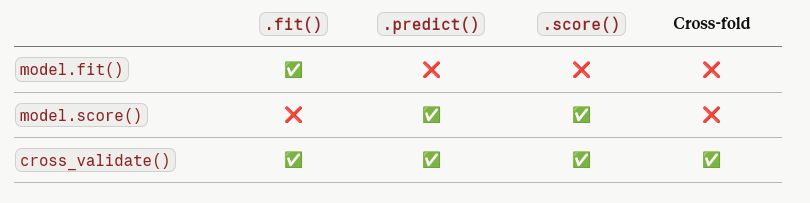

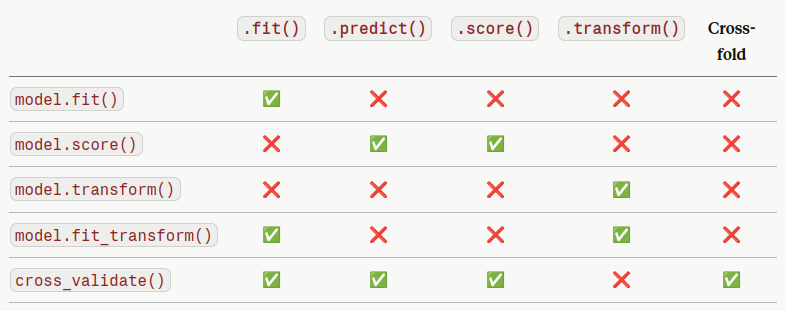

In [10]:
dummy = DummyClassifier(strategy='most_frequent')

In [11]:
scores = cross_validate(dummy, X_train, y_train, return_train_score=True, cv=5) # do cross validation using 5-folds
scores

{'fit_time': array([0.00132775, 0.00108171, 0.00103664, 0.00070286, 0.00070429]),
 'score_time': array([0.00131416, 0.00142479, 0.00117636, 0.00078201, 0.00079107]),
 'test_score': array([0.5       , 0.5       , 0.5       , 0.5       , 0.53846154]),
 'train_score': array([0.50961538, 0.50961538, 0.50961538, 0.50961538, 0.5       ])}

In [12]:
pd.DataFrame(scores)

,fit_time,score_time,test_score,train_score
0,0.001328,0.001314,0.500000,0.509615
1,0.001082,0.001425,0.500000,0.509615
2,0.001037,0.001176,0.500000,0.509615
3,0.000703,0.000782,0.500000,0.509615
4,0.000704,0.000791,0.538462,0.500000


In [13]:
print('mean validation test score:', scores['test_score'].mean())

mean validation test score: 0.5076923076923077


In [14]:
knn = KNeighborsClassifier()
scores = cross_validate(knn, X_train, y_train, return_train_score=True, cv=5) # do cross validation using 5-folds
pd.DataFrame(scores)

,fit_time,score_time,test_score,train_score
0,0.004254,0.006361,0.346154,0.663462
1,0.002325,0.003525,0.423077,0.711538
2,0.001577,0.002439,0.576923,0.663462
3,0.001348,0.002140,0.615385,0.663462
4,0.001346,0.002086,0.615385,0.663462


In [15]:
print('mean validation test score:', scores['test_score'].mean())

mean validation test score: 0.5153846153846153


In [16]:
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [17]:
knn.predict(X_test)

array(['PG', 'PF', 'PG', 'PG', 'PF', 'PG', 'PG', 'PG', 'PG', 'PF', 'PG',
       'PF', 'PG', 'PF', 'PG', 'PG', 'PG', 'PG', 'PG', 'PG', 'PF', 'PG',
       'PG', 'PF', 'PG', 'PG', 'PF', 'PG', 'PG', 'PG', 'PF', 'PF', 'PF'],
      dtype=object)

We see that the dummy classifier (supposed to be the baseline, i.e. the worst) performs almost same as KNN. Why? 

In [19]:
# take a subsample of the training set, here just pick two different players, i.e. two rows of the dataframe
two_players=X_train.sample(2, random_state=42)
two_players

,AST,Age,Salary
107,3.4,32,11457217
101,0.4,30,12690000


The values in the `AST` columns are around 1 and in `Age` are 20. The values in `Salary` are much higher. 

In [20]:
euclidean_distances(two_players) # two_players = input matrix of shape n_samples_X = 2, n_features=3

array([[      0.        , 1232783.00000526],
       [1232783.00000526,       0.        ]])

In [21]:
euclidean_distances(two_players)[1,0]

np.float64(1232783.0000052599)

In [22]:
two_players_subset = two_players[['Salary']]
two_players_subset

,Salary
107,11457217
101,12690000


In [23]:
euclidean_distances(two_players_subset)[1,0] #shows that only the salary variable plays a role

np.float64(1232783.0)

The distance is completely dominated by the features with larger values. The features with smaller values are being ignored. This is not good: 
- Features on smaller scales can be highly informative. No reason to be ignored. 
- Want model to be robust and not sensitive to scale

To solve that, scale columns so that they all use similar range of values: `StandardScaler`

`StandardScaler` is called a _transformer_

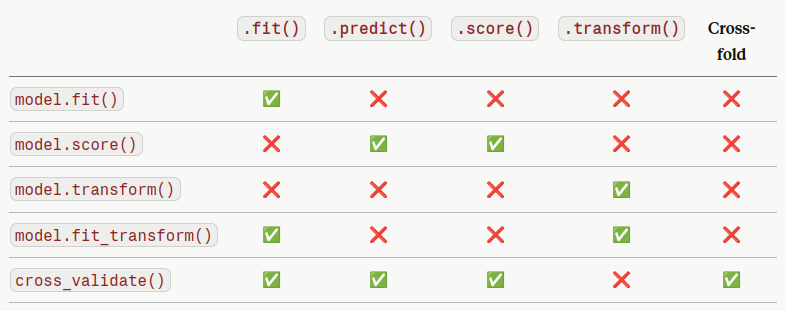

### Transformers: Scaling example

In [25]:
from sklearn.preprocessing import StandardScaler

Steps to do scaling: 
1. Create a feature transformer object. Done in a similar way as creating a model. Transformers accept hyperparameters as well. 
2. Fit transformer on train split
3. Transform the train split using `transform()`
4. Transform the test split 

In [26]:
scaler = StandardScaler() #create feature transformer object 
scaler.fit(X_train) #fitting the transformer on the train split

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [27]:
X_train_scaled = scaler.transform(X_train)
X_train_scaled

array([[ 3.06586603, -0.93523952, -0.46409137],
       [ 1.885362  ,  1.73198836,  2.97543968],
       [-0.80130233,  1.50971937, -0.56914829],
       [-0.67918123,  1.28745038,  0.18526392],
       [ 0.33849466,  0.17610543,  0.24081534],
       [-0.39423198, -0.04616356, -0.32986607],
       [-1.04554455, -0.04616356, -0.78688664],
       [ 1.55970572,  1.95425735,  1.01754728],
       [-1.16766565, -0.26843255, -0.76148253],
       [-0.67918123,  0.39837442, -0.65498688],
       [-0.43493902, -1.15750851, -0.55788656],
       [-0.67918123, -0.71297053, -0.6768583 ],
       [ 1.15263536, -0.49070154,  0.5216585 ],
       [-0.63847419, -0.04616356, -0.45375642],
       [ 1.35617054, -0.04616356,  1.4230312 ],
       [-0.96413048, -1.3797775 , -0.6768583 ],
       [-0.1906968 ,  0.17610543, -0.31886496],
       [-0.80130233,  0.17610543, -0.59168403],
       [ 1.1933424 ,  0.39837442,  2.04211705],
       [-0.80130233, -0.49070154, -0.29975254],
       [ 0.66415094, -0.71297053, -0.489

In [28]:
X_test_scaled = scaler.transform(X_test)

In [29]:
pd.DataFrame(X_train_scaled, columns=X_train.columns).head()

,AST,Age,Salary
0,3.065866,-0.935240,-0.464091
1,1.885362,1.731988,2.975440
2,-0.801302,1.509719,-0.569148
3,-0.679181,1.287450,0.185264
4,0.338495,0.176105,0.240815


In [30]:
X_train.head()

,AST,Age,Salary
216,10.4,22,4215120
2,7.5,34,47080179
258,0.9,33,2905851
102,1.2,32,12307692
97,3.7,27,13000000


#### Sklearn's predict vs transform

In [31]:
knn.fit(X_train, y_train)
X_train_prediction = knn.predict(X_train)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler.fit(X_train, [y_train]) #not necessary to pass y_train but still do it to be consistent with usual syntax
X_train_transformed = scaler.transform(X_train)

# or X_train_transformed = scaler.fit_transform(X_train) fitting and transforming in one call 

In [33]:
knn_unscaled = KNeighborsClassifier()
knn_unscaled.fit(X_train, y_train)

print('Train score', knn_unscaled.score(X_train, y_train))
print('Test score', knn_unscaled.score(X_test, y_test))

Train score 0.6692307692307692
Test score 0.48484848484848486


In [47]:
#Do scaling

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Do fitting
knn_scaled = KNeighborsClassifier()
knn_scaled.fit(X_train_scaled, y_train)
print('Results using transorm and then fit:')
print('Train score', knn_scaled.score(X_train_scaled, y_train))
print('Test score', knn_scaled.score(X_test_scaled, y_test)) #does `score` also do the predict?
print('\n')
print('Results using fit_tranform:')
# #Do scaling and fitting in one step
X_train_scaled = scaler.fit_transform(X_train)
print('Train score', knn_scaled.score(X_train_scaled, y_train))
print('Test score', knn_scaled.score(X_test_scaled, y_test))

Results using transorm and then fit:
Train score 0.7923076923076923
Test score 0.7575757575757576


Results using fit_tranform:
Train score 0.7923076923076923
Test score 0.7575757575757576


We now see that the k-NN is doing much better than DummyClassifier, when we scale our features.

Rewriting the whole example with all the steps in one cell:

In [49]:
# --- SCALING ---
scaler = StandardScaler()
scaler.fit(X_train)                        # learns mean and std from train data
X_train_scaled = scaler.transform(X_train) # applies scaling to train
X_test_scaled = scaler.transform(X_test)   # applies same scaling to test

# --- FITTING THE MODEL ---
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)           # learns from scaled train data

# --- TRAIN SCORE ---
y_train_pred = knn.predict(X_train_scaled) # predicts on scaled train data
train_score = accuracy_score(y_train, y_train_pred)  # compares to true labels
print('Train score', train_score)

# --- TEST SCORE ---
y_test_pred = knn.predict(X_test_scaled)   # predicts on scaled test data
test_score = accuracy_score(y_test, y_test_pred)     # compares to true labels
print('Test score', test_score)

Train score 0.7923076923076923
Test score 0.7575757575757576


We can write the same thing in a concise version 

In [50]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit + transform combined
X_test_scaled = scaler.transform(X_test) # only transform on test

knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train) # fit on scaled data

knn.score(X_train_scaled, y_train)   # predict + accuracy_score combined
knn.score(X_test_scaled, y_test)     # predict + accuracy_score combined

print('Train score:', knn.score(X_train_scaled, y_train))
print('Test score:', knn.score(X_test_scaled, y_test))

Train score: 0.7923076923076923
Test score: 0.7575757575757576


### Preprocessing with imputation

In [51]:
housing_df = pd.read_csv('../Data/kagglehub/datasets/harrywang/housing/versions/4/housing.csv')
housing_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [52]:
train_df, test_df = train_test_split(housing_df, test_size=0.1, random_state=121)
train_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
4074,-118.43,34.14,44.0,1693.0,239.0,498.0,216.0,10.9237,500001.0,<1H OCEAN
8130,-118.18,33.80,15.0,2407.0,589.0,1591.0,506.0,3.0513,148100.0,NEAR OCEAN
11210,-117.92,33.82,10.0,1548.0,506.0,1535.0,424.0,4.5057,152400.0,<1H OCEAN
13898,-116.62,34.23,14.0,6438.0,1719.0,1586.0,691.0,1.6136,67400.0,INLAND
10188,-117.96,33.87,27.0,890.0,289.0,416.0,200.0,3.1410,167500.0,<1H OCEAN


Calculate variables that are useful for our prediction

In [53]:
train_df = train_df.assign(rooms_per_household=train_df['total_rooms']/train_df['households'], 
                           bedrooms_per_household=train_df['total_bedrooms']/train_df['households'],
                           population_per_household=train_df['population']/train_df['households'])


test_df = test_df.assign(rooms_per_household=test_df['total_rooms']/test_df['households'], 
                           bedrooms_per_household=test_df['total_bedrooms']/test_df['households'],
                           population_per_household=test_df['population']/test_df['households'])

train_df = train_df.drop(columns=['total_rooms', 'total_bedrooms', 'population'])
test_df = test_df.drop(columns=['total_rooms', 'total_bedrooms', 'population'])

train_df.head()

,longitude,latitude,housing_median_age,households,median_income,median_house_value,ocean_proximity,rooms_per_household,bedrooms_per_household,population_per_household
4074,-118.43,34.14,44.0,216.0,10.9237,500001.0,<1H OCEAN,7.837963,1.106481,2.305556
8130,-118.18,33.80,15.0,506.0,3.0513,148100.0,NEAR OCEAN,4.756917,1.164032,3.144269
11210,-117.92,33.82,10.0,424.0,4.5057,152400.0,<1H OCEAN,3.650943,1.193396,3.620283
13898,-116.62,34.23,14.0,691.0,1.6136,67400.0,INLAND,9.316932,2.487699,2.295224
10188,-117.96,33.87,27.0,200.0,3.1410,167500.0,<1H OCEAN,4.450000,1.445000,2.080000


In [54]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18576 entries, 4074 to 11586
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   longitude                 18576 non-null  float64
 1   latitude                  18576 non-null  float64
 2   housing_median_age        18576 non-null  float64
 3   households                18576 non-null  float64
 4   median_income             18576 non-null  float64
 5   median_house_value        18576 non-null  float64
 6   ocean_proximity           18576 non-null  object 
 7   rooms_per_household       18576 non-null  float64
 8   bedrooms_per_household    18387 non-null  float64
 9   population_per_household  18576 non-null  float64
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [55]:
train_df.describe()

,longitude,latitude,housing_median_age,households,median_income,median_house_value,rooms_per_household,bedrooms_per_household,population_per_household
count,18576.000000,18576.000000,18576.000000,18576.000000,18576.000000,18576.000000,18576.000000,18387.000000,18576.000000
mean,-119.559326,35.624266,28.608904,498.952143,3.862688,206467.234981,5.431458,1.098289,3.082747
std,2.000498,2.134838,12.581171,378.496871,1.891618,115327.558519,2.531547,0.492448,10.940403
min,-124.300000,32.540000,1.000000,1.000000,0.499900,14999.000000,0.846154,0.333333,0.750000
25%,-121.780000,33.930000,18.000000,281.000000,2.559875,119300.000000,4.443644,1.006202,2.430380
50%,-118.490000,34.250000,29.000000,410.000000,3.531300,179200.000000,5.226924,1.049020,2.820594
75%,-118.000000,37.710000,37.000000,603.000000,4.738700,264600.000000,6.057889,1.100000,3.282977
max,-114.310000,41.950000,52.000000,6082.000000,15.000100,500001.000000,141.909091,34.066667,1243.333333


In [56]:
#training data is missing 189 values for bedrooms_per_household
train_df['bedrooms_per_household'].isnull().sum()

np.int64(189)

In [57]:
X_train = train_df.drop(columns=['median_house_value', 'ocean_proximity']) # drop ocean_proxomity because categorical variables and haven't seen how to deal with that yet. 
y_train = train_df['median_house_value']

X_test = test_df.drop(columns=['median_house_value', 'ocean_proximity'])
y_test = test_df['median_house_value']

In [58]:
#this shows the problem that the model has when trying to fit on missing data
knn = KNeighborsRegressor()
knn.fit(X_train, y_train)

ValueError: Input X contains NaN.
KNeighborsRegressor does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

Classifier not able to deal with missing values. How to deal with this? 

1. Dropping rows with NaNs
    - Drop rows (need to do same in test set). 
    - Problematic if we get a missing value in deployment
    - What if missing values don't occur at random? For ex., a certain type of house contributes to more missing values
    $\to$ not great solution especially if a lot of missing values   
2. Dropping a column
    - Drop all columns with missing values
    - Throws away a lot of information just for a small percentage of missing values
    - Dropping a column is most values are missing makes sense.

#### Imputation

"Inventing" values for missing data. 

- Categorical columns: most frequent value.
- Numerical columns: mean or median of column or a 
constant

In [59]:
from sklearn.impute import SimpleImputer

In [63]:
X_train.sort_values('bedrooms_per_household').tail(20)

,longitude,latitude,housing_median_age,households,median_income,rooms_per_household,bedrooms_per_household,population_per_household
18332,-122.16,37.45,47.0,1093.0,4.2297,3.873742,NaN,1.654163
3529,-118.53,34.26,18.0,550.0,8.1760,6.680000,NaN,2.890909
2412,-119.45,36.61,24.0,243.0,3.7917,5.358025,NaN,2.851852
14462,-117.27,32.85,26.0,268.0,4.4250,5.123134,NaN,2.268657
6241,-117.97,34.06,31.0,497.0,3.2413,5.062374,NaN,4.414487
4600,-118.27,34.04,13.0,682.0,1.7038,2.615836,NaN,3.164223
9970,-122.48,38.50,37.0,439.0,4.3125,6.945330,NaN,2.931663
17825,-121.88,37.40,9.0,1438.0,5.3400,4.694715,NaN,2.948540
6220,-117.91,34.05,35.0,500.0,5.0758,6.378000,NaN,3.454000
17639,-121.90,37.28,26.0,535.0,5.6427,7.020561,NaN,2.631776


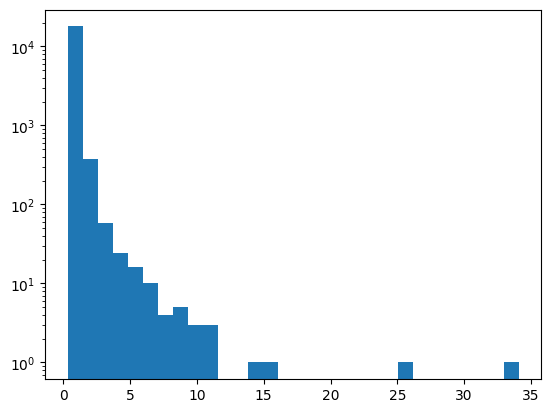

In [67]:
import matplotlib.pyplot as plt
plt.hist(X_train['bedrooms_per_household'], bins=30)
plt.yscale('log')

In [68]:
imputer = SimpleImputer(strategy='median')
imputer.fit(X_train)
X_train_imp = imputer.transform(X_train)
X_test_imp = imputer.transform(X_test)
X_train_imp

array([[-118.43      ,   34.14      ,   44.        , ...,    7.83796296,
           1.10648148,    2.30555556],
       [-118.18      ,   33.8       ,   15.        , ...,    4.756917  ,
           1.16403162,    3.14426877],
       [-117.92      ,   33.82      ,   10.        , ...,    3.6509434 ,
           1.19339623,    3.62028302],
       ...,
       [-121.54      ,   36.99      ,   27.        , ...,    5.94710327,
           1.13098237,    4.48866499],
       [-118.26      ,   34.07      ,   40.        , ...,    2.73092369,
           1.09638554,    3.99598394],
       [-118.01      ,   33.79      ,   30.        , ...,    6.2278481 ,
           1.02025316,    3.23291139]], shape=(18576, 8))

In [71]:
X_train_imp_df = pd.DataFrame(X_train_imp, columns=X_train.columns)
X_train_imp_df.loc[[7763]]

,longitude,latitude,housing_median_age,households,median_income,rooms_per_household,bedrooms_per_household,population_per_household
7763,-122.0,36.93,51.0,302.0,3.1932,5.350993,1.238411,2.013245


Now that we filled the gaps, can train on data with the new data X_train_imp

In [74]:
knn = KNeighborsRegressor()
knn.fit(X_train_imp, y_train)
knn.score(X_train_imp, y_train)

0.559981787703631

In [75]:
knn.score(X_test_imp, y_test)

0.31201291051327185

Not great results though...

### Preprocessing with scaling and normalizing

Focusing on two scaling (normalizing) methods:
- StandardScaler()
- MinMaxScaler()

Start with imputed data from california housing dataset.

In [80]:
pd.DataFrame(X_train_imp, columns=X_train_imp_df.columns, index=X_train.index).head()

,longitude,latitude,housing_median_age,households,median_income,rooms_per_household,bedrooms_per_household,population_per_household
4074,-118.43,34.14,44.0,216.0,10.9237,7.837963,1.106481,2.305556
8130,-118.18,33.80,15.0,506.0,3.0513,4.756917,1.164032,3.144269
11210,-117.92,33.82,10.0,424.0,4.5057,3.650943,1.193396,3.620283
13898,-116.62,34.23,14.0,691.0,1.6136,9.316932,2.487699,2.295224
10188,-117.96,33.87,27.0,200.0,3.1410,4.450000,1.445000,2.080000


In [81]:
from sklearn.preprocessing import StandardScaler

In [98]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp) #transform only, don't fit 

pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index).head()

,longitude,latitude,housing_median_age,households,median_income,rooms_per_household,bedrooms_per_household,population_per_household
4074,0.564538,-0.695278,1.223377,-0.747588,3.732890,0.950632,0.017743,-0.071041
8130,0.689510,-0.854545,-1.081717,0.018621,-0.428950,-0.266461,0.135205,0.005624
11210,0.819481,-0.845176,-1.479147,-0.198031,0.339936,-0.703350,0.195139,0.049134
13898,1.469337,-0.653119,-1.161203,0.507410,-1.189008,1.534863,2.836855,-0.071985
10188,0.799485,-0.821755,-0.127885,-0.789862,-0.381529,-0.387702,0.708671,-0.091658


In [111]:
X_train_imp[:,0]

array([-118.43, -118.18, -117.92, ..., -121.54, -118.26, -118.01],
      shape=(18576,))

0 longitude
1 latitude
2 housing_median_age
3 households
4 median_income
5 rooms_per_household
6 bedrooms_per_household
7 population_per_household


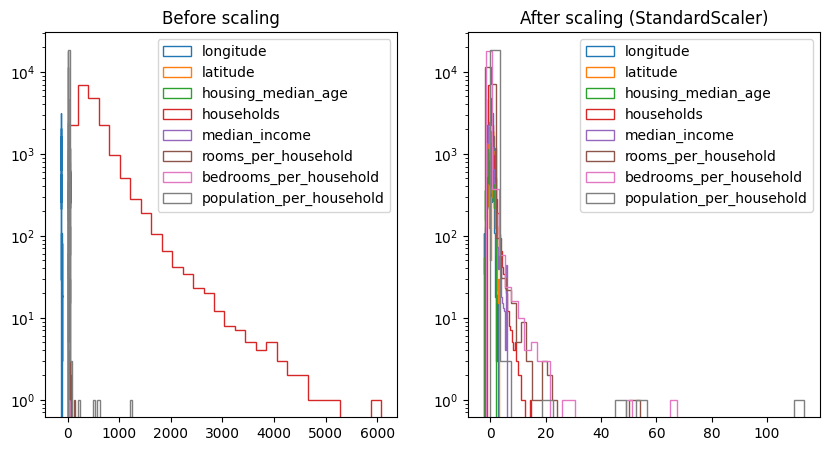

In [127]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

for i, col in enumerate(X_train.columns):

    print(i, col)
    # fig, ax = plt.subplots()
    ax1.hist(X_train_imp[:,i], bins=30, label=col, histtype='step')
    ax1.legend()
    ax1.set_yscale('log')
    ax1.set_title('Before scaling')

    ax2.hist(X_train_scaled[:,i], bins=30, label=col, histtype='step')
    ax2.legend()
    ax2.set_yscale('log')
    ax2.set_title('After scaling (StandardScaler)')

Unscaled data

In [134]:
knn = KNeighborsRegressor()
knn.fit(X_train_imp, y_train)
print(round(knn.score(X_train_imp, y_train),4))

print(round(knn.score(X_test_imp, y_test),4))

0.56
0.312


Scaled data

In [135]:
knn = KNeighborsRegressor()
knn.fit(X_train_scaled, y_train)
print(round(knn.score(X_train_scaled, y_train),4))

print(round(knn.score(X_test_scaled, y_test),4))

0.7976
0.6826


$\to$ significant increase in training and testing scores

Let's now see MinMaxScaler.

In [136]:
from sklearn.preprocessing import MinMaxScaler

In [146]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp)

pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index).head()


,longitude,latitude,housing_median_age,households,median_income,rooms_per_household,bedrooms_per_household,population_per_household
4074,0.587588,0.170032,0.843137,0.035356,0.718873,0.049565,0.022919,0.001252
8130,0.612613,0.133900,0.274510,0.083046,0.175956,0.027724,0.024625,0.001927
11210,0.638639,0.136026,0.176471,0.069561,0.276258,0.019883,0.025496,0.002310
13898,0.768769,0.179596,0.254902,0.113468,0.076806,0.060050,0.063865,0.001244
10188,0.634635,0.141339,0.509804,0.032725,0.182142,0.025548,0.032955,0.001070


0 longitude
1 latitude
2 housing_median_age
3 households
4 median_income
5 rooms_per_household
6 bedrooms_per_household
7 population_per_household


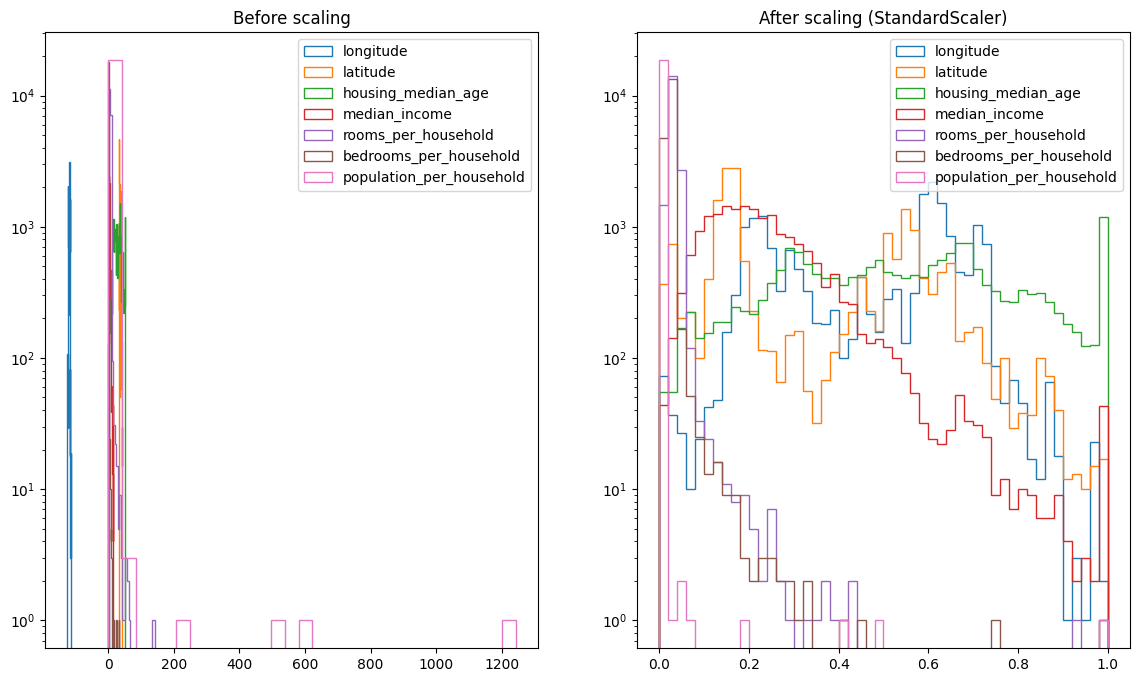

In [147]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))

for i, col in enumerate(X_train.columns):
    print(i, col)

    if i!=3:
        # fig, ax = plt.subplots()
        ax1.hist(X_train_imp[:,i], bins=30, label=col, histtype='step')
        ax1.legend()
        ax1.set_yscale('log')
        ax1.set_title('Before scaling')

        ax2.hist(X_train_scaled[:,i], bins=50, label=col, histtype='step')
        ax2.legend()
        ax2.set_yscale('log')
        ax2.set_title('After scaling (StandardScaler)')

In [ ]:
knn = KNeighborsRegressor()
knn.fit(X_train_scaled, y_train)
print(round(knn.score(X_train_scaled, y_train),4))
print(round(knn.score(X_test_scaled, y_test),4))

0.8038
0.7


0 longitude
1 latitude
2 housing_median_age
3 households
4 median_income
5 rooms_per_household
6 bedrooms_per_household
7 population_per_household


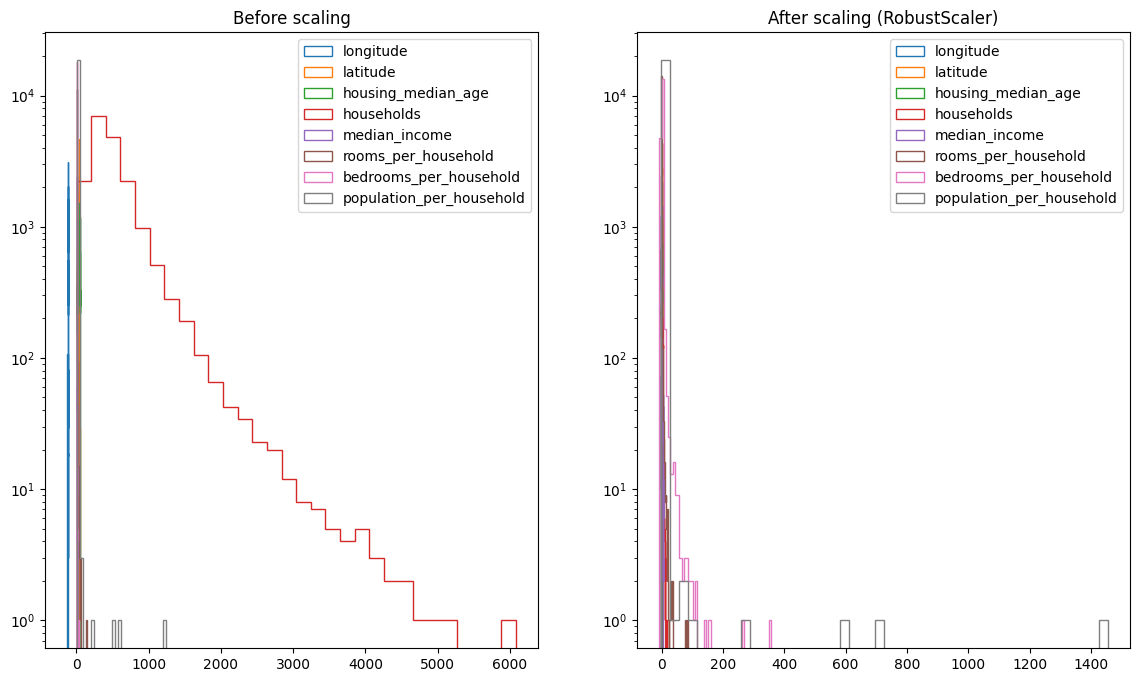

In [149]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp)

pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index).head()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))

for i, col in enumerate(X_train.columns):
    print(i, col)

    ax1.hist(X_train_imp[:,i], bins=30, label=col, histtype='step')
    ax1.legend()
    ax1.set_yscale('log')
    ax1.set_title('Before scaling')

    ax2.hist(X_train_scaled[:,i], bins=50, label=col, histtype='step')
    ax2.legend()
    ax2.set_yscale('log')
    ax2.set_title('After scaling (RobustScaler)')

In [150]:
knn = KNeighborsRegressor()
knn.fit(X_train_scaled, y_train)
print(round(knn.score(X_train_scaled, y_train),4))
print(round(knn.score(X_test_scaled, y_test),4))

0.7965
0.6711


### Pipelines

We have our scaled data:

In [151]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp) #transform only, don't fit 

Up to now, just calculated the score but we saw that realistic assessment is doing **cross-validation**

In [152]:
knn = KNeighborsRegressor()
scores = cross_validate(knn, X_train_scaled, y_train, return_train_score=True)
pd.DataFrame(scores)

,fit_time,score_time,test_score,train_score
0,0.025038,0.138870,0.699050,0.792089
1,0.011579,0.179402,0.676600,0.793491
2,0.012213,0.178822,0.702225,0.787997
3,0.011650,0.167609,0.681686,0.794007
4,0.011468,0.174160,0.664234,0.797549


There's a problem with this way of doing! Validation data shouldn't influence our training data. But here we are scaling both training and validation data first, before we perform cross-validation $\to$ information from validation data is influencing training data. 
In other words, information from validation dataset leaked into training step. 

Solution to this problem is to use **pipelines**! Works in consecutive steps:

1. Transformers
2. Model

In [153]:
from sklearn.pipeline import Pipeline

In [154]:
pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("reg", KNeighborsRegressor())
])

In [155]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. I

What's actually happening

```
imputer.fit(X_train)
X_train_imp = imputer.transform(X_train)
scaler.fit(X_train_imp)
X_train_imp_scaled = scaler.transform(X_train_imp)
knn.fit(X_train_imp_scaled)
```

In [156]:
pipe.predict(X_train)

array([500001., 162760., 193820., ..., 240620., 133300., 233280.],
      shape=(18576,))

In [158]:
scores_processed = cross_validate(pipe, X_train, y_train, return_train_score=True)
pd.DataFrame(scores_processed)

,fit_time,score_time,test_score,train_score
0,0.025238,0.169369,0.715923,0.801294
1,0.021940,0.172737,0.674315,0.793453
2,0.021027,0.172650,0.700311,0.786612
3,0.020880,0.167216,0.677360,0.792660
4,0.020674,0.167313,0.664304,0.796394


In [159]:
pd.DataFrame(scores_processed).mean()

fit_time       0.021952
score_time     0.169857
test_score     0.686443
train_score    0.794082
dtype: float64

In [162]:
from sklearn.dummy import DummyRegressor

dummy = DummyRegressor(strategy='median')
scores = cross_validate(dummy, X_train, y_train, return_train_score=True)
pd.DataFrame(scores).mean()

fit_time       0.002761
score_time     0.000919
test_score    -0.056475
train_score   -0.056152
dtype: float64

Now model works and KNN model performs way better than Dummy, which makes no sense.

### Automated hyperparameters optimization

**The problem with hyperparameters**
- There's a lot of hyperparameters. 
- Picking reasonable hyperparameters is important $\to$ avoid underfit or overfit models
- Nobody knows exactly how to choose them 
- May interact with each other in unexpected ways
- Best settings depend on specific data/problem
- Can take a long time to execute 

**Methods**
- There are two hyperparameters optimization methods:

    1. GridSearchCV
    2. RandomizedSearchCV 

CV stands for cross-validation. These searchers have cross-validation built in. 

In [190]:
cities_df = pd.read_csv("../Data/canada_usa_cities.csv")
cities_df = cities_df.drop(columns=["Unnamed: 0"])
cities_df.head()

,longitude,latitude,country
0,-69.7487,42.7266,USA
1,-115.6821,28.3843,USA
2,-74.6350,39.4678,USA
3,-139.1803,81.8543,Canada
4,-122.2292,49.2276,Canada


In [191]:
train_df, test_df = train_test_split(cities_df, test_size=0.2, random_state=123)
X_train, y_train  = train_df.drop(columns=['country']), train_df['country']
X_test, y_test  = test_df.drop(columns=['country']), test_df['country']
X_train.head()

,longitude,latitude
512,-85.3314,29.0178
685,-100.1331,58.7471
997,-92.1407,58.1173
927,-54.2626,74.5361
376,-109.6862,42.5132


Exhaustive grid search

In [192]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

We will use a SVM classifier $\to$ hyperparameters are C and gamma.

In [193]:
param_grid = {
    "gamma": [0.1, 1., 10., 100.]
}

In [194]:
svc = SVC()

grid_search = GridSearchCV(svc, param_grid, verbose=1)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'gamma': [0.1, 1.0, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter indexes are also d

In [195]:
param_grid = {
    "gamma": [0.1, 1., 10., 100.],
    "C": [0.1, 1., 10., 100.]
}

svc = SVC()

grid_search = GridSearchCV(svc, param_grid, cv=5, verbose=1, n_jobs=-1) #n_jobs=-1 run hyperparameter optimization in parallel instead of in a sequence

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1.0, ...], 'gamma': [0.1, 1.0, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter i

In [196]:
grid_search.best_params_ #shows the best params

{'C': 1.0, 'gamma': 0.1}

Implement with pipelines 

In [197]:
# 1. Specify steps of pipeline
pipe = Pipeline(
    steps = [
        ("imputer", SimpleImputer(strategy='median')),
        ("scaler", StandardScaler()),
        ("svc", SVC())
    ]
)

# 2. Specify set of values for each hyperparameter in param_grid
# Syntax is "svc__<hyperparameter>" because otherwise the pipeline doesn't know which hyperparameter goes with each step (could be imputer or scaler hyperparams)
param_grid = {
    "svc__gamma": [0.1, 1., 10., 100.],
    "svc__C": [0.1, 1., 10., 100.]
}

In [198]:
grid_search = GridSearchCV(pipe, param_grid, cv=5, return_train_score=True, verbose=1)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...svc', SVC())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'svc__C': [0.1, 1.0, ...], 'svc__gamma': [0.1, 1.0, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- 

In [199]:
grid_search.best_params_

{'svc__C': 1.0, 'svc__gamma': 1.0}

In [200]:
grid_search.best_score_

np.float64(0.93125)

In [201]:
grid_search.best_estimator_ #the best model, i.e. the whole pipeline is stored in best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. I

In [ ]:
best_model = grid_search.best_estimator_
best_model.fit(X_train, y_train) # why do we need to refit? 

In [204]:
best_model.score(X_test, y_test)

0.945

In [205]:
grid_search.score(X_test, y_test)

0.945

In [206]:
best_model.predict(X_test)

array(['Canada', 'Canada', 'USA', 'Canada', 'Canada', 'Canada', 'Canada',
       'USA', 'Canada', 'Canada', 'USA', 'USA', 'Canada', 'Canada', 'USA',
       'Canada', 'USA', 'USA', 'USA', 'USA', 'USA', 'Canada', 'USA',
       'USA', 'USA', 'Canada', 'USA', 'USA', 'Canada', 'USA', 'Canada',
       'USA', 'Canada', 'Canada', 'USA', 'USA', 'Canada', 'Canada', 'USA',
       'USA', 'Canada', 'USA', 'USA', 'USA', 'Canada', 'Canada', 'Canada',
       'USA', 'USA', 'Canada', 'Canada', 'USA', 'USA', 'Canada', 'USA',
       'USA', 'Canada', 'USA', 'Canada', 'Canada', 'USA', 'USA', 'USA',
       'USA', 'USA', 'Canada', 'Canada', 'USA', 'Canada', 'Canada',
       'Canada', 'USA', 'Canada', 'Canada', 'USA', 'USA', 'Canada',
       'Canada', 'USA', 'USA', 'Canada', 'Canada', 'USA', 'USA', 'Canada',
       'USA', 'USA', 'Canada', 'USA', 'USA', 'Canada', 'USA', 'USA',
       'USA', 'USA', 'USA', 'Canada', 'Canada', 'USA', 'USA', 'Canada',
       'USA', 'USA', 'USA', 'USA', 'Canada', 'USA', 'USA', 'USA'

**Problems**

- Required number of models to evaluate grows exponentionally with the dimension of config space
- Exhaustive search may become infeasible fairly quickly (5 hyperparameters with 10 possible values: $10^5 = 100,000$ models)

$\to$ **Randomized hyperparameter search**

In [207]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
param_grid = {
    "svc__gamma": [0.1, 1., 10., 100.],
    "svc__C": [0.1, 1., 10., 100.]
}
random_search = RandomizedSearchCV(pipe, param_grid, cv=5, verbose=1, n_jobs=-1, n_iter=10) #n_iter -> pick a random subset containing the specified number of combinations
random_search.fit(X_train, y_train)
random_search.score(X_test, y_test)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


0.95

For randomize grid search, we can also search over a range of continuous values

In [211]:
import scipy

In [213]:
param_grid = {
    "svc__gamma": scipy.stats.uniform(0, 100),
    "svc__C": scipy.stats.uniform(0, 100)
}

random_gs = RandomizedSearchCV(pipe, param_grid, n_jobs=-1, cv=10, verbose=1, n_iter=10)
random_gs.fit(X_train, y_train)

Fitting 10 folds for each of 10 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...svc', SVC())])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'svc__C': <scipy.stats....x73195b183020>, 'svc__gamma': <scipy.stats....x73195a995d60>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value 

In [214]:
random_gs.best_params_

{'svc__C': np.float64(7.164401581404545),
 'svc__gamma': np.float64(66.11389452247418)}

In [215]:
random_gs.best_score_

np.float64(0.91875)

In [ ]:
random_gs.score(X_test, y_test) # I think it's underfitting?

0.92

#### Overfitting on the validation set

Carrying out hyperparameter optimization has the effect of repeating cross-validation over and over again $\to$ not necessarily unseen data anymore. May produce overly optimistic results. 
If dataset is small and validation set hit too many times, **optimization bias** or **overfitting validation set**.
- Optimization bias grows with the number of things we try.
- Optimization bias shrinks quickly with number of examples (but still non-zero and growing if overusing validation set.)

Even more concise + avoid data leakage with pipeline.

```
pipe.fit(X_train, y_train):
  1. scaler.fit(X_train)
  2. X_train_scaled = scaler.transform(X_train)
  3. knn.fit(X_train_scaled, y_train)

pipe.score(X_test, y_test):
  1. X_test_scaled = scaler.transform(X_test)   ← uses stats from X_train, no leakage
  2. y_pred = knn.predict(X_test_scaled)
  3. accuracy_score(y_test, y_pred)
```

In [35]:
# --- BUILD PIPELINE ---
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

# --- FIT ---
pipe.fit(X_train, y_train)         # internally: scaler.fit_transform(X_train) → knn.fit(X_train_scaled)

# --- SCORE ---
pipe.score(X_train, y_train)       # internally: scaler.transform(X_train) → knn.predict → accuracy_score
pipe.score(X_test, y_test)         # internally: scaler.transform(X_test) → knn.predict → accuracy_score

# print('Train score:', pipe.score(X_train_scaled, y_train))
# print('Test score:', pipe.score(X_test_scaled, y_test))


#with cross validate
results = cross_validate(pipe, X, y, return_train_score=True, cv=2)  # fit + scale + predict + score × 5 folds, no leakage
# print(results['test_score'].mean())
results

/home/sbron/ProductivityStudy/venv_prod/lib/python3.12/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(


{'fit_time': array([0.00337434, 0.00314999]),
 'score_time': array([0.0029726 , 0.00290537]),
 'test_score': array([0.22222222, 0.25751073]),
 'train_score': array([0.51502146, 0.51282051])}

### Final compact form of everything for scaling example

In [37]:
# --- LOAD DATA ---
df = pd.read_csv('../Data/kagglehub/datasets/jamiewelsh2/nba-player-salaries-2022-23-season/versions/2/nba_2022-23_all_stats_with_salary.csv')

# --- DEFINE X AND y ---
X = df[['AST', 'Age', 'Salary']]   # features
y = df['Position']                 # target — the column you want to predict

# --- TRAIN/TEST SPLIT ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- BUILD PIPELINE ---
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

# --- FIT AND SCORE ---
pipe.fit(X_train, y_train)
# Less reliable — one lucky/unlucky split
print('Train score:', pipe.score(X_train, y_train))
print('Test score:', pipe.score(X_test, y_test))

# --- OPTIONAL: CROSS VALIDATION ---
# More reliable — averaged over 5 splits
results = cross_validate(pipe, X, y, cv=5)
print('CV scores - mean:', results['test_score'].mean())
print('CV scores: - std', results['test_score'].std())

Train score: 0.5040214477211796
Test score: 0.20212765957446807
CV scores - mean: 0.27185998627316404
CV scores: - std 0.03804103377971642


/home/sbron/ProductivityStudy/venv_prod/lib/python3.12/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
